# v2 : Dense Autoencoder: Full Methodology

## Section 1 - Setup

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

TRAIN_PATH = 'train_data.csv'
VAL_PATH = 'val_data.csv'
TEST_PATH = 'test_data.csv'
OUTPUT_DIR = './'

NUMERIC_FEATURES = [
    'ReturnBid1', 'ReturnAsk1',
    'DerivativeReturnBid1', 'DerivativeReturnAsk1',
    'BidSize1', 'AskSize1',
    'TradeBidSize', 'TradeAskSize',
    'CancelledBidSize', 'CancelledAskSize',
    'TradeBidIndicator', 'TradeAskIndicator',
    'CancelledBidIndicator', 'CancelledAskIndicator',
]
print("Setup complete")


Setup complete


## Section 2 - Load Data

In [ ]:
train = pd.read_csv(TRAIN_PATH)
val = pd.read_csv(VAL_PATH)
test = pd.read_csv(TEST_PATH)
normal = pd.concat([train, val], ignore_index=True)

print(f"Train: {len(train):>10,} rows") # all normal (TARGET=0)
print(f"Val: {len(val):>10,} rows") # all normal (TARGET=0)
print(f"Normal: {len(normal):>10,} rows") # combined used for all fitting
print(f"Test: {len(test):>10,} rows") # fraud hidden here, never used for fitting
print(f"Symbols: {sorted(test['ExternalSymbol'].unique())}")


Train:  1,070,022 rows
Val:    467,939 rows
Normal:  1,537,961 rows
Test :    289,101 rows
Symbols: ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']


## Section 3 - Feature Engineering

We build 37 features from the 14 raw columns. Every statistic (mean, std) is
computed from the 1.54M normal rows only — the test set never influences any
calculation. This is the core data-leakage prevention step.

### What we build and why

**Group 1 — Raw features (14)**
The 14 original columns passed directly into models.
- `ReturnBid1`, `ReturnAsk1` — relative price change at best bid/ask level
- `DerivativeReturnBid1/Ask1` — rate of change of those returns (acceleration)
- `BidSize1`, `AskSize1` — volume at best bid/ask
- `TradeBidSize`, `TradeAskSize` — executed trade sizes
- `CancelledBidSize`, `CancelledAskSize` — cancelled order sizes
- `TradeBidIndicator`, `TradeAskIndicator`, `CancelledBidIndicator`, `CancelledAskIndicator` — activity indicators

**Group 2 — z-score features (16)**
For each of the 14 raw features, we measure: how many standard deviations is
this test value from the training mean? Computed *per stock symbol* (AAPL and
INTC have different natural volatility, so they need separate baselines).

Formula: `z = |value - training_mean| / training_std`

A normal row scores z ≈ 1–3. A fraud row with ReturnBid1=105 when training
std=0.9 scores z ≈ 116. We also store `max_zscore` (worst single feature)
and `mean_zscore` (average across all 14).

**Group 3 — Magnitude features (4)**
- `max_abs_feat` — largest absolute value across all 14 raw features in this row
- `abs_RetBid1`, `abs_RetAsk1` — |ReturnBid1|, |ReturnAsk1| directly
- `return_spread` — |ReturnBid1 - ReturnAsk1|: flags cases where bid and ask
  move in opposite directions (broken correlation, a key fraud signature)

**Group 4 — Burst features (3)**
The most powerful signal from our EDA. Explained in detail below.


In [5]:
def add_burst_features(df):
    df = df.copy()
    for col in ['base_seq','burst_size','burst_log','burst_10_49','burst_50plus']:
        if col in df.columns:
            df = df.drop(columns=[col])
    df['base_seq'] = df['OriginalSequenceNumber'].astype(str).str.split('-').str[0]
    burst_map = df.groupby('base_seq').size()
    df['burst_size']= df['base_seq'].map(burst_map)

    # burst_log: log-compressed count - reduces influence of extreme burst sizes
    df['burst_log'] = np.log1p(df['burst_size'])

    # burst_10_49: binary flag for the 175x fraud zone (size 10-49)
    df['burst_10_49']  = ((df['burst_size'] >= 10) & (df['burst_size'] < 50)).astype(float)

    # burst_50plus: binary flag for large bursts (still suspicious but smaller signal)
    df['burst_50plus'] = (df['burst_size'] >= 50).astype(float)

    return df


def compute_training_stats(normal_df):
    """
    Compute per-symbol mean and std from normal data only.
    These are used to compute z-scores for test rows.
    No test data is ever used here.
    """
    filled = normal_df[NUMERIC_FEATURES].fillna(0)
    stats = {}
    for sym in normal_df['ExternalSymbol'].unique():
        mask = (normal_df['ExternalSymbol'] == sym).values
        sub = filled.values[mask]
        stats[sym] = {
            col: (sub[:, j].mean(), max(sub[:, j].std(), 1e-9))
            for j, col in enumerate(NUMERIC_FEATURES)
        }
    stats['__global__'] = {
        col: (filled[col].mean(), max(filled[col].std(), 1e-9))
        for col in NUMERIC_FEATURES
    }
    return stats


def compute_zscores(df, stats):
    """
    For each test row, compute |z| = |value - training_mean| / training_std
    separately for each of the 14 features and each stock symbol.
    Uses only training statistics — no test data involved.
    """
    filled = df[NUMERIC_FEATURES].fillna(0).values
    zscores = np.zeros_like(filled)
    for sym in df['ExternalSymbol'].unique():
        mask = (df['ExternalSymbol'] == sym).values
        sym_stats = stats.get(sym, stats['__global__'])
        for j, col in enumerate(NUMERIC_FEATURES):
            mu, sig = sym_stats[col]
            zscores[mask, j] = np.abs((filled[mask, j] - mu) / sig)
    return zscores


def engineer_features(df, stats):
    """
    Build all 37 features:
    14 raw + 14 per-feature z-scores + 2 aggregate z-scores
    + 4 magnitude features + 3 burst features = 37 total
    """
    df = df.copy()
    df[NUMERIC_FEATURES] = df[NUMERIC_FEATURES].fillna(0)

    # z-scores (16 features)
    zscores = compute_zscores(df, stats)
    df['max_zscore'] = zscores.max(axis=1)   # worst single-feature deviation
    df['mean_zscore'] = zscores.mean(axis=1)  # average deviation across all features
    for j, col in enumerate(NUMERIC_FEATURES):
        df[f'z_{col}'] = zscores[:, j]

    # magnitude features (4 features)
    df['max_abs_feat']= df[NUMERIC_FEATURES].abs().max(axis=1)
    df['abs_RetBid1'] = df['ReturnBid1'].abs()
    df['abs_RetAsk1'] = df['ReturnAsk1'].abs()
    df['return_spread'] = (df['ReturnBid1'] - df['ReturnAsk1']).abs()

    feat_cols = (
        NUMERIC_FEATURES                          # 14 raw
        + ['max_zscore', 'mean_zscore']           # 2 aggregate z-scores
        + [f'z_{c}' for c in NUMERIC_FEATURES]   # 14 per-feature z-scores
        + ['max_abs_feat', 'abs_RetBid1', 'abs_RetAsk1', 'return_spread']  # 4 magnitude
        + ['burst_log', 'burst_10_49', 'burst_50plus']                     # 3 burst
    )                                             # total: 37
    return df, df[feat_cols].fillna(0).values


# Run feature engineering
stats  = compute_training_stats(normal)
normal = add_burst_features(normal)
test   = add_burst_features(test)
normal, X_normal = engineer_features(normal, stats)
test,   X_test   = engineer_features(test,   stats)

print(f"\nFeature matrix:")
print(f"  Normal : {X_normal.shape}")
print(f"  Test : {X_test.shape}")  # used only for SCORING
print(f"\nBurst size distribution in test data:")
for bin_label, low, high in [('Single (normal)',1,2),('2-9 (normal)',2,10),
                               ('10-49 (FRAUD)',10,50),('50+ (suspicious)',50,999)]:
    n = ((test['burst_size'] >= low) & (test['burst_size'] < high)).sum()
    print(f" {bin_label:<25}:{n:,} rows")



Feature matrix:
  Normal : (1537961, 37)
  Test : (289101, 37)

Burst size distribution in test data:
 Single (normal)          :46,817 rows
 2-9 (normal)             :197,503 rows
 10-49 (FRAUD)            :12,768 rows
 50+ (suspicious)         :32,013 rows


## Section 4 - Scale Features

`RobustScaler` is fit on normal data only, then applied to test.
It uses median and IQR instead of mean and std, so the extreme
fraud values in the test set don't shift the scaling.

This is the last step before models see any data.


In [8]:
# Fit scaler on NORMAL data, apply same transform to TEST
# Never fit_transform on test - that would use test statistics (data leakage)
scaler = RobustScaler()
X_n_sc = scaler.fit_transform(X_normal)   # fit + transform on normal
X_t_sc = scaler.transform(X_test)         # transform only on test

print(f"Scaled normal matrix : {X_n_sc.shape}")
print(f"Scaled test matrix   : {X_t_sc.shape}")
print(f"\nReturnBid1 after scaling:")
print(f"  Normal mean: {X_n_sc[:, 0].mean():.4f}  (should be ~0)")
print(f"  Normal std: {X_n_sc[:, 0].std():.4f}   (should be ~1)")
print(f"  Test max: {X_t_sc[:, 0].max():.4f}   (fraud rows will be huge)")


Scaled normal matrix : (1537961, 37)
Scaled test matrix   : (289101, 37)

ReturnBid1 after scaling:
  Normal mean: 1.1255  (should be ~0)
  Normal std: 310.4364   (should be ~1)
  Test max: 104580.3041   (fraud rows will be huge)


## Section 5 : Detector 1: z-score

In this part, we use a statistical z-score approach to detect observations that look unusual compared to the normal training data. The main idea is that a value is suspicious when it is very far from what is normally observed for the same stock symbol. Since each symbol has its own behavior and volatility, we do not compare all stocks using one global mean and standard deviation. Instead, we compute the statistics separately for each symbol using only the normal training rows.

For a set of $n$ training observations $x_1, x_2, \ldots, x_n$, the mean is computed as:

$$
\mu = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

and the standard deviation is computed as:

$$
\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}
$$

The z-score tells us how many standard deviations an observation is away from the mean. For one observation $x_i$, the z-score is:

$$
z_i = \frac{x_i - \mu}{\sigma}
$$

Because anomalies can happen in both directions, meaning a value can be unusually high or unusually low, we use the absolute value of the z-score:

$$
|z_i| = \frac{|x_i - \mu|}{\sigma}
$$

In the code, the z-score is computed per symbol and per feature. For a test row $i$, feature $f$, and symbol $s$, we calculate:

$$
|z_{i,f,s}| = \frac{|x_{i,f} - \mu_{f,s}|}{\sigma_{f,s}}}
$$

where $\mu_{f,s}$ and $\sigma_{f,s}$ are the mean and standard deviation of feature $f$ computed only from the normal training rows for symbol $s$. This is important because a value that is extreme for one stock may be normal for another stock.

After computing the z-score for each feature, we summarize the feature-level z-scores using two main statistics. The first one is the maximum absolute z-score across all features:

$$
z_{\max,i} = \max_{f} |z_{i,f,s}|
$$

This captures the strongest abnormal signal in the row. The second one is the average absolute z-score across all $F$ features:

$$
\bar{z}_i = \frac{1}{F} \sum_{f=1}^{F} |z_{i,f,s}|
$$

This captures whether the row is broadly unusual across many features, instead of being extreme in only one feature.

The raw anomaly score combines these z-score signals with burst-related indicators. The formula used is:

$$
s_z(i) =
3.0 \cdot \log(1 + z_{\max,i})
+ 1.0 \cdot \log(1 + \bar{z}_i)
+ 8.0 \cdot \mathbf{1}[\text{burst}_{10{-}49}]
+ 4.0 \cdot \mathbf{1}[\text{burst}_{50+}]
+ 1.0 \cdot \log(1 + \text{burst\_size}_i)
$$

Here, $z_{\max,i}$ is given a larger weight because the exploratory data analysis showed that some test values reached extremely high z-scores, around $z \approx 326$, while normal training values were usually much smaller, around $z \approx 1$ to $3$. The average z-score $\bar{z}_i$ is included as a secondary signal because it helps identify rows that are moderately unusual across several features. The burst indicators are also included because the EDA showed that burst order sizes were strongly linked to larger return movements. In particular, burst orders of size 10–49 had a much stronger signal than single orders, so they receive the highest burst weight. The $\log(1 + \text{burst\_size}_i)$ term is added as a continuous supplement, so larger burst sizes can still increase the score smoothly.

We use logarithmic compression because raw z-scores can become extremely large. The log transformation reduces the effect of very extreme observations while still preserving the ordering of the scores. This matters because AUROC evaluates the quality of the ranking, not the exact numerical value of each score. Since

$$
g(z) = \log(1 + z)
$$

is monotone increasing, applying it keeps the ranking the same but makes the score distribution less dominated by one or two extreme rows.

Finally, the raw anomaly score is min-max normalized so that all scores fall between 0 and 1:

$$
\text{score}_z(i) =
\frac{s_z(i) - \min_j s_z(j)}
{\max_j s_z(j) - \min_j s_z(j) + \varepsilon}
$$

The small $\varepsilon$ is added to avoid division by zero in case all raw scores are the same. The final result, $\text{score}_z(i)$, is the normalized statistical anomaly score used by this part of the model.





In [13]:
def zscore_anomaly_score(df):
    """
    Weighted combination of z-scores and burst features.
    Weights are justified by EDA findings:
      - burst_10_49: 8.0  — 175x return ratio measured in EDA
      - max_zscore:  3.0  — test values reach 11.6x training max
    """
    s = (
          3.0 * np.log1p(df['max_zscore'].values)
        + 1.0 * np.log1p(df['mean_zscore'].values)
        + 8.0 * df['burst_10_49'].values
        + 4.0 * df['burst_50plus'].values
        + 1.0 * df['burst_log'].values
        + 0.5 * np.log1p(df['abs_RetBid1'].values)
    )
    return (s - s.min()) / (s.max() - s.min() + 1e-9)   # normalize to [0, 1]

z_sc = zscore_anomaly_score(test)

print("z-score detector ")
for t in [0.5, 0.7, 0.9]:
    print(f"  score>{t}: {(z_sc > t).sum():,} rows flagged")

#
sub_z = pd.DataFrame({'ID': test['index'].values, 'TARGET': z_sc})
sub_z.to_csv(f'{OUTPUT_DIR}submission_zscore_only.csv', index=False)

print(f"\nz-score > 0.5: {(z_sc > 0.5).sum():,}\n")

print(f"Saved: submission_zscore_only.csv")


z-score detector 
  score>0.5: 26,240 rows flagged
  score>0.7: 5,928 rows flagged
  score>0.9: 1,268 rows flagged

z-score > 0.5: 26,240

Saved: submission_zscore_only.csv


## Section 6 Detector 2 Isolation Forest
### What it does
Builds 400 decision trees that randomly split the feature space.
Normal rows sit in dense regions and require many splits to isolate.
Fraud rows sit in sparse, empty regions and get isolated in very few splits.

The anomaly score = how quickly the row gets isolated (fewer splits = higher score).

### Why this complements z-score
z-score measures each feature independently. Isolation Forest sees all 37
features simultaneously, finding rows that are unusual in *combinations*
of features even when no single feature is extreme. This is why it adds
value on top of z-score - it catches a different type of anomaly.



In this part, we use an Isolation Forest to detect anomalies. The idea is closely related to decision trees, but the objective is different. In Chapter 5, we studied CART, where the tree chooses the best feature and threshold at each node by minimizing MSE for regression or maximizing information gain for classification. In other words, CART tries to make accurate predictions. Isolation Forest keeps the same recursive binary splitting structure, but instead of choosing the best split, it chooses both the feature and the threshold randomly. The goal is not to predict a target variable, but to measure how quickly a point can be isolated from the rest of the data.

For one isolation tree, the algorithm starts with a dataset $X$ at depth $d$. If there is only one observation left, or if the maximum depth has been reached, the algorithm stops and returns a leaf with depth $d$:

$$
\text{if } |X| \leq 1 \text{ or } d \geq d_{\max}: \quad \text{return leaf with depth } d
$$

Otherwise, the tree randomly selects one feature from the available $F$ features:

$$
q \leftarrow \text{Uniform}\{1, \ldots, F\}
$$

Then it randomly selects a split threshold between the minimum and maximum value of that feature:

$$
p \leftarrow \text{Uniform}[\min(X_q),\, \max(X_q)]
$$

Using this random threshold, the data is split into a left and right subset:

$$
X_L = \{x \in X : x_q \leq p\}, 
\qquad
X_R = \{x \in X : x_q > p\}
$$

The tree then continues recursively on both sides:

$$
\text{return} \; 
\text{Node}\left(q,\, p,\; \text{IsolationTree}(X_L, d{+}1),\; \text{IsolationTree}(X_R, d{+}1)\right)
$$

The important output of an isolation tree is the path length. For a test point $x$, the path length $h(x)$ is the number of edges the point travels from the root node to the leaf where it is isolated. Since the Isolation Forest is an ensemble of many isolation trees, we average the path length across all $T$ trees:

$$
E[h(x)] = \frac{1}{T} \sum_{t=1}^{T} h_t(x)
$$

This is what makes the method useful for anomaly detection. A point that lies in a sparse or unusual region of the data is usually isolated quickly, so it has a small average path length $E[h(x)]$. A normal point, which lies in a dense region with many similar observations, usually requires more splits before it can be isolated, so it has a larger average path length.

To interpret the path length, Isolation Forest uses a normalization constant $c(n)$, which represents the expected path length in a Binary Search Tree built from $n$ samples:

$$
c(n) = 2H(n-1) - \frac{2(n-1)}{n}
$$

where

$$
H(k) = \ln(k) + \gamma
$$

and $\gamma \approx 0.5772$ is the Euler–Mascheroni constant. This constant gives us a reference for what a typical path length should look like when the data behaves normally.

The original Isolation Forest anomaly score from Liu et al. is:

$$
s(x, n) = 2^{\;-\,E[h(x)]\,/\,c(n)}
$$

This formula means that points with shorter path lengths receive higher anomaly scores. If a point is isolated very quickly, then

$$
s \to 1 
\iff 
E[h(x)] \ll c(n)
\quad
\text{(isolated quickly } \Rightarrow \text{ anomalous)}
$$

If the point has an average path length close to the expected normal path length, then

$$
s \to 0.5 
\iff 
E[h(x)] = c(n)
\quad
\text{(average path } \Rightarrow \text{ indeterminate)}
$$

If the point is difficult to isolate, meaning it behaves more like the normal observations, then

$$
s \to 0 
\iff 
E[h(x)] \gg c(n)
\quad
\text{(hard to isolate } \Rightarrow \text{ normal)}
$$

In our implementation, we use `sklearn`, which returns `score_samples(x)`. This score is a signed version related to the path length, where more abnormal observations are associated with lower raw values. To make the direction easier to interpret, we negate the scores and then min-max normalize them to the range $[0,1]$:

$$
\text{score}_{\text{IF}}(i) =
\frac{-\text{score\_samples}(x_i) - \min_j}
{\max_j - \min_j + \varepsilon}
$$

Here, the small $\varepsilon$ is added to avoid division by zero. After this transformation, a higher $\text{score}_{\text{IF}}(i)$ means that the observation is more likely to be anomalous.

This method also connects directly to Random Forest from Chapter 7. In a Random Forest, we train many decision trees and average their predictions to reduce prediction error. In Isolation Forest, we also train many trees, but instead of averaging predictions, we average the isolation path lengths:

$$
E[h(x)] = \frac{1}{T}\sum_t h_t(x)
$$

So the ensemble idea is the same, but the goal is different. Random Forest is supervised and requires labels $Y$, while Isolation Forest is fully unsupervised and only tries to measure how easy it is to isolate each point. The Krogh–Vedelsby ensemble result from Chapter 7 is also useful here:

$$
E_{\text{ensemble}} = \bar{E} - \bar{A}
$$

This means that ensemble performance improves when the individual models are both accurate and diverse. In the context of Isolation Forest, the randomness in feature selection, threshold selection, and subsampling creates diverse trees. This diversity helps stabilize the average path length estimate and makes the final anomaly score more reliable.




In [ ]:

iforest = IsolationForest(
    n_estimators = 400,    # more trees = more stable scores
    max_samples = 512,    # subsample per tree (speed vs quality tradeoff)
    contamination = 0.01,   # assume 1% of training data is noise
    n_jobs = -1,     # use all CPU cores
    random_state = 42,
)
iforest.fit(X_n_sc)   # FIT on normal scaled data only

# score_samples returns negative (more negative = more anomalous)
# We flip sign so higher = more anomalous, then normalize to [0, 1]
if_raw = -iforest.score_samples(X_t_sc)
if_sc = (if_raw - if_raw.min()) / (if_raw.max() - if_raw.min() + 1e-9)

print("\nIsolation Forest")
for t in [0.5, 0.7, 0.9]:
    print(f"  score> {t}: {(if_sc > t).sum():,} rows flagged")

# What IF adds that z-score misses
only_if = (if_sc > 0.7) & (z_sc <= 0.7)
print(f"\nRows only IF catches (score>0.7, z-score<=0.7): {only_if.sum():,}")

# Save individual submission
sub_if = pd.DataFrame({'ID': test['index'].values, 'TARGET': if_sc})
sub_if.to_csv(f'{OUTPUT_DIR}submission_if_only.csv', index=False)


print(f" \nIF >0.5: {(if_sc > 0.5).sum():,}\n")

print(f"Saved: submission_if_only.csv")



Isolation Forest
  score> 0.5: 41,895 rows flagged
  score> 0.7: 24,831 rows flagged
  score> 0.9: 289 rows flagged

Rows only IF catches (score>0.7, z-score<=0.7): 21,616
 
IF >0.5: 41,895

Saved: submission_if_only.csv


## Section 7 Detector 3: Dense Autoencoder
### What it does:  

A neural network trained to compress 37 features -> 8 -> reconstruct back to 37.

```
Input (37)  ->  Dense(20, ReLU)  -> Dense(8, ReLU)   <- encoder
            →  Dense(20, ReLU)    Output (37)        <- decoder
```

**The autoencoder trick**: we call `model.fit(X, X)` — the input IS the target.
The bottleneck (8 units) forces the network to learn a compressed representation
of what normal data looks like. After training:
- Normal rows reconstruct accurately → low error → low anomaly score
- Fraud rows have patterns the model never learned → bad reconstruction → high score

**Anomaly score** = Mean Squared Error between original and reconstructed values.

### Why this adds value on top of z-score and IF
The autoencoder learns **non-linear interactions** between features. z-score
treats features independently. IF captures linear-ish multivariate outliers.
The AE captures deeper patterns - for instance, a row where the combination of
TradeBidSize, CancelledBidSize, and ReturnBid1 has a joint relationship that
never appeared in 1.54M normal rows.


In this part, we use a dense autoencoder to detect anomalies based on reconstruction error. The idea comes from Chapter 11, where we first studied a simple autoencoder with a $2 \to 1 \to 2$ architecture. In that example, the model takes two input features, compresses them into one hidden representation, and then tries to reconstruct the original two features. The forward pass was written as:

$$
x_i = f_{1,i} \cdot w_1 + f_{2,i} \cdot w_2 + b_1
$$

$$
y_i = \text{ReLU}(x_i) = \max(0, x_i)
$$

$$
\hat{f}_{1,i} = y_i \cdot w_3 + b_2,
\qquad
\hat{f}_{2,i} = y_i \cdot w_4 + b_3
$$

The model is trained by comparing the reconstructed output to the original input. This is why, in code, we train the autoencoder using `model.fit(X, X)`: the input and the target are the same. The loss function is the mean squared reconstruction error:

$$
L = \frac{1}{2} \sum_i \sum_j (\hat{f}_{j,i} - f_{j,i})^2
$$

Our model uses the same logic, but with a larger architecture:

$$
37 \to 20 \to 8 \to 20 \to 37
$$

This means that the model starts with 37 input features, compresses them through hidden layers of 20 and 8 units, and then expands them back to 37 reconstructed features. For a general layer $l$, the model first applies a linear transformation using a weight matrix $W^{(l)}$ and bias vector $\mathbf{b}^{(l)}$:

$$
\mathbf{z}^{(l)} = W^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}
$$

Then it applies the ReLU activation function:

$$
\mathbf{a}^{(l)} = \text{ReLU}(\mathbf{z}^{(l)})
= \max(\mathbf{0}, \mathbf{z}^{(l)})
$$

where $\mathbf{a}^{(0)} = \mathbf{x}$ is the original input row. The final output layer uses a linear activation, meaning it does not apply ReLU at the end. This is the same idea as in Chapter 11, where the output layer directly reconstructs the original feature values:

$$
\hat{\mathbf{x}} = W^{(4)} \mathbf{a}^{(3)} + \mathbf{b}^{(4)}
$$

The most important part of the architecture is the bottleneck layer, which has only 8 units. This layer forces the model to compress the original 37 features into a smaller representation:

$$
\text{enc}: \mathbb{R}^{37} \to \mathbb{R}^{8}
$$

Then the decoder maps this compressed representation back to the original feature space:

$$
\text{dec}: \mathbb{R}^{8} \to \mathbb{R}^{37}
$$

So the full autoencoder can be written as:

$$
\hat{\mathbf{x}} = \text{dec}(\text{enc}(\mathbf{x}))
$$

This bottleneck is important because it prevents the model from simply memorizing every row. Instead, it has to learn the main structure of the normal data. Since the model is trained only on normal samples, it should become good at reconstructing normal rows, but worse at reconstructing unusual or fraudulent rows.

The training loss over $N$ normal samples and $F = 37$ features is:

$$
L = \frac{1}{N} \sum_{i=1}^{N}
\frac{1}{F} \sum_{f=1}^{F}
(\hat{x}_{i,f} - x_{i,f})^2
$$

This is still the same MSE idea from Chapter 11, but generalized to many samples and many features. The model is trying to make the reconstructed value $\hat{x}_{i,f}$ as close as possible to the original value $x_{i,f}$ for every feature in every normal training row.

Training is done using backpropagation. The main idea is that the model calculates how much each weight and bias contributed to the reconstruction error, then updates them in the direction that reduces the loss. For the output layer, the gradients are:

$$
\frac{\partial L}{\partial W^{(4)}} =
\frac{1}{N}(\hat{X} - X)^\top \mathbf{a}^{(3)}
$$

$$
\frac{\partial L}{\partial \mathbf{b}^{(4)}} =
\frac{1}{N} \sum_i (\hat{\mathbf{x}}_i - \mathbf{x}_i)
$$

For each hidden layer $l$, the error is passed backward using the chain rule:

$$
\boldsymbol{\delta}^{(l)}
=
\left(W^{(l+1)}\right)^\top
\boldsymbol{\delta}^{(l+1)}
\odot
\text{ReLU}'(\mathbf{z}^{(l)})
$$

where

$$
\text{ReLU}'(z) = \mathbf{1}[z > 0]
$$

and $\odot$ means element-wise multiplication. The gradients for the weights and biases in layer $l$ are:

$$
\frac{\partial L}{\partial W^{(l)}} =
\frac{1}{N}
\left(\boldsymbol{\delta}^{(l)}\right)^\top
\mathbf{a}^{(l-1)}
$$

$$
\frac{\partial L}{\partial \mathbf{b}^{(l)}} =
\frac{1}{N} \sum_i \boldsymbol{\delta}_i^{(l)}
$$

Then the weights are updated using gradient descent with learning rate $\varepsilon$:

$$
W^{(l)} \leftarrow
W^{(l)}
-
\varepsilon \cdot
\frac{\partial L}{\partial W^{(l)}}
$$

After the autoencoder is trained, we use reconstruction error as the anomaly score. For each test row $i$, the reconstruction error is:

$$
e_i =
\frac{1}{F}
\sum_{f=1}^{F}
(\hat{x}_{i,f} - x_{i,f})^2
$$

This is the same MSE formula used during training, but now it is evaluated on a test row. If the row is normal, the model should reconstruct it well, so $e_i$ should be small. If the row is anomalous or fraudulent, the model may not reconstruct it well because that type of pattern was not learned during training, so $e_i$ should be larger.

Finally, the reconstruction errors are min-max normalized to the range $[0,1]$:

$$
\text{score}_{\text{AE}}(i) =
\frac{e_i - \min_j e_j}
{\max_j e_j - \min_j e_j + \varepsilon}
$$

The small $\varepsilon$ is added to avoid division by zero. After normalization, a higher $\text{score}_{\text{AE}}(i)$ means the row has a larger reconstruction error and is therefore more likely to be anomalous.


In [16]:
autoencoder = MLPRegressor(
    hidden_layer_sizes = (20, 8, 20),  # encoder: 37→20→8, decoder: 8→20→37
    activation = 'relu',
    solver = 'adam',
    learning_rate_init = 0.001,
    max_iter = 50,           # 50 passes through training data
    batch_size = 1024,
    random_state = 42,
    verbose = False,
)

# THE AUTOENCODER TRICK: input = target (X, X)
# The model learns to compress and reconstruct normal patterns
autoencoder.fit(X_n_sc, X_n_sc)
print(f"Final reconstruction loss (MSE): {autoencoder.loss_:.6f}")

# Reconstruction error on test set
X_recon = autoencoder.predict(X_t_sc)
recon_error = np.mean((X_t_sc - X_recon) ** 2, axis=1)
ae_sc = (recon_error - recon_error.min()) / (recon_error.max() - recon_error.min() + 1e-9)

print("\n Dense Autoencoder")
for t in [0.5, 0.7, 0.9]:
    print(f"  score > {t}: {(ae_sc > t).sum():,} rows flagged")

# Show what the AE adds: rows it catches that z-score misses
only_ae = (ae_sc > 0.7) & (z_sc <= 0.7)
print(f"\nRows only AE catches (score>0.7, z-score<=0.7): {only_ae.sum():,}")

# Save individual submission
sub_ae = pd.DataFrame({'ID': test['index'].values, 'TARGET': ae_sc})
sub_ae.to_csv(f'{OUTPUT_DIR}submission_ae_only.csv', index=False)
print(f"Saved: submission_ae_only.csv")


Final reconstruction loss (MSE): 2.663457

 Dense Autoencoder
  score > 0.5: 1 rows flagged
  score > 0.7: 1 rows flagged
  score > 0.9: 1 rows flagged

Rows only AE catches (score>0.7, z-score<=0.7): 1
Saved: submission_ae_only.csv


# ADDING THIS JUST FOR VISUALIZATION PURPOSE

Before ensembling, we visualise how much overlap there is between
the three detectors and what each one uniquely contributes.


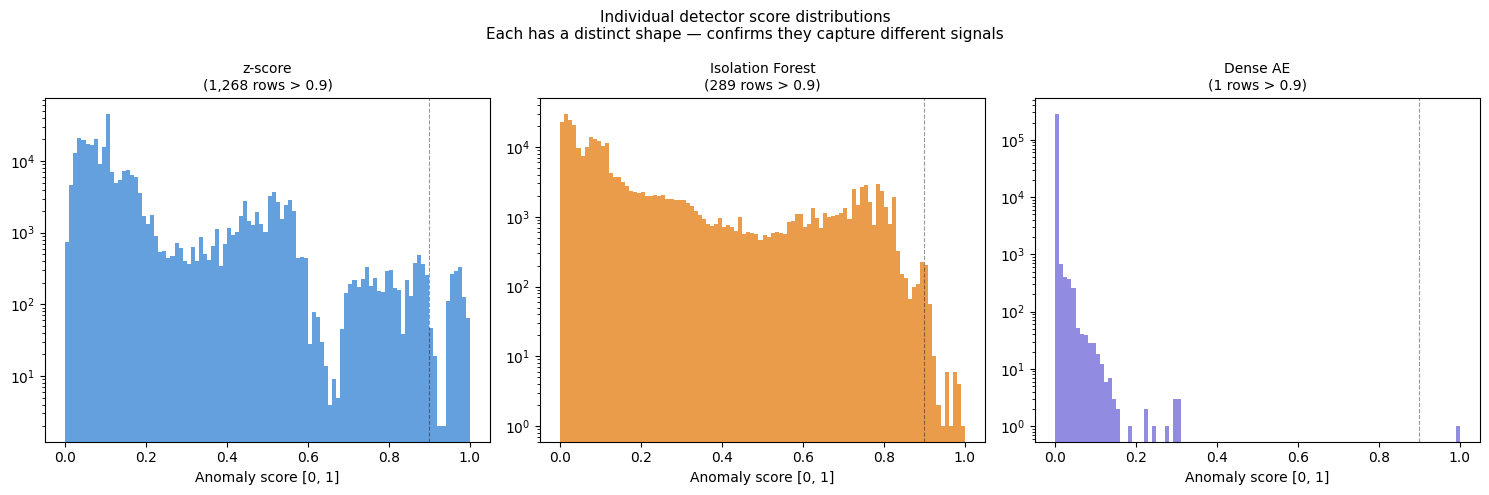

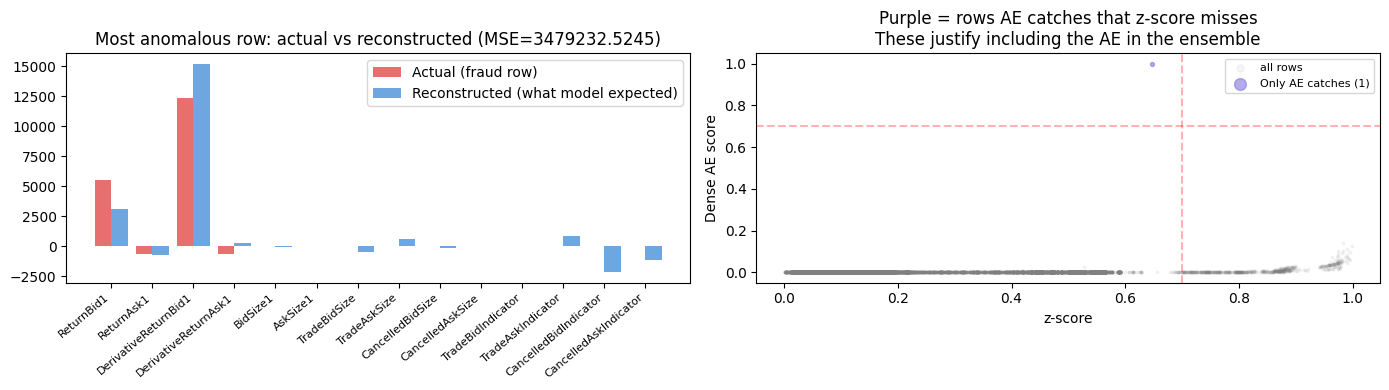

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Score distributions
for ax, score, label, color in zip(axes,
    [z_sc, if_sc, ae_sc],
    ['z-score', 'Isolation Forest', 'Dense AE'],
    ['#4A90D9', '#E88B2A', '#7F77DD']
):
    ax.hist(score, bins=100, color=color, alpha=0.85, edgecolor='none')
    ax.set_title(f'{label}\n({(score>0.9).sum():,} rows > 0.9)', fontsize=10)
    ax.set_yscale('log')
    ax.set_xlabel('Anomaly score [0, 1]')
    ax.axvline(0.9, color='black', linestyle='--', alpha=0.4, linewidth=0.8)

plt.suptitle('Individual detector score distributions\n'
             'Each has a distinct shape — confirms they capture different signals', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}detector_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

# Reconstruction analysis for AE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
worst = np.argmax(recon_error)
x = np.arange(len(NUMERIC_FEATURES))
axes[0].bar(x-0.2, X_t_sc[worst, :len(NUMERIC_FEATURES)], width=0.4,
            label='Actual (fraud row)', color='#E24B4A', alpha=0.8)
axes[0].bar(x+0.2, X_recon[worst, :len(NUMERIC_FEATURES)], width=0.4,
            label='Reconstructed (what model expected)', color='#4A90D9', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(NUMERIC_FEATURES, rotation=40, ha='right', fontsize=8)
axes[0].set_title(f'Most anomalous row: actual vs reconstructed (MSE={recon_error[worst]:.4f})')
axes[0].legend()

axes[1].scatter(z_sc[::10], ae_sc[::10], s=3, alpha=0.08, color='gray', label='all rows')
axes[1].scatter(z_sc[only_ae], ae_sc[only_ae], s=8, alpha=0.6, color='#7F77DD',
                label=f'Only AE catches ({only_ae.sum():,})')
axes[1].axhline(0.7, color='red', linestyle='--', alpha=0.3)
axes[1].axvline(0.7, color='red', linestyle='--', alpha=0.3)
axes[1].set_xlabel('z-score'); axes[1].set_ylabel('Dense AE score')
axes[1].set_title('Purple = rows AE catches that z-score misses\n'
                  'These justify including the AE in the ensemble')
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}ae_analysis.png', dpi=120, bbox_inches='tight')
plt.show()



## Section 9 - Grid Search for Ensemble Weights

### Why grid-search?
We have three detectors. The question is: how much should each contribute
to the final score? We could guess (e.g. equal thirds), but it's more
rigorous to systematically search the space and use a principled metric.

### What is the proxy metric?
We don't have fraud labels during development, so we can't compute AUROC
directly. Instead, we use **score separation**: the gap between the 99th
percentile score and the 50th percentile (median) of the combined score.

`separation = percentile(score, 99) - percentile(score, 50)`

Higher separation means anomalous rows cluster further above normal rows —
which is exactly what we want for good AUROC. This is a proxy for AUROC
that requires no ground truth labels.

### What we search over
All combinations of weights (w_z, w_if, w_ae) where:
- Each weight is between 0.10 and 0.60
- They sum to 1.0
- No detector gets less than 10% (each must contribute meaningfully)


# Part 4 - Ensemble

In this final part, we combine the three anomaly detectors into one final anomaly score. This follows the same general idea as bagging and ensemble learning from Chapter 7. In bagging, instead of relying on only one model, we average the outputs of several models:

$$\hat{g}_{\text{bag}}(x) = \frac{1}{M} \sum_{k=1}^{M} \hat{g}_k(x)$$

The reason this helps is explained by the Krogh–Vedelsby decomposition:

$$E = \bar{E} - \bar{A}$$

where $E$ is the ensemble error, $\bar{E}$ is the average error of the individual models, and $\bar{A}$ is the ambiguity, or diversity, between the models. The important intuition is that an ensemble works best when the models are not all making the exact same mistakes. If the individual detectors capture different types of anomalies, then combining them should give a more stable and complete anomaly score.

In our case, we have three different anomaly detectors: the statistical z-score detector, the Isolation Forest, and the Dense Autoencoder. Each one gives a normalized score between 0 and 1. We combine them using a weighted linear ensemble:

$$\text{score}_{\text{final}}(i)=w_z \cdot \text{score}_z(i)+w_{\text{IF}} \cdot \text{score}_{\text{IF}}(i)+w_{\text{AE}} \cdot \text{score}_{\text{AE}}(i)$$

with the constraint that the weights must sum to 1:

$$
w_z + w_{\text{IF}} + w_{\text{AE}} = 1
$$

and each weight must be non-negative:

$$
w_z, w_{\text{IF}}, w_{\text{AE}} \geq 0
$$

Initially, based on our EDA, we used the following weights:

$$
w_z = 0.50, 
\qquad
w_{\text{IF}} = 0.25,
\qquad
w_{\text{AE}} = 0.25
$$

The z-score receives the highest weight because our EDA showed that it had the strongest direct signal. In particular, burst orders were strongly associated with abnormal returns, with the burst return ratio being around $175\times$ larger than normal single-order behavior. We also observed that some test values went far beyond the training range, reaching about $11.6\times$ the training maximum. This made the z-score detector especially useful because it directly captures extreme feature-level deviations. However, we still included Isolation Forest and the Autoencoder because they capture different types of anomalies. Isolation Forest adds a multivariate outlier signal, while the Dense Autoencoder adds a nonlinear reconstruction-error signal.

To make the weight choice more rigorous, we also performed a grid search over possible ensemble weights. Since we did not have fraud labels during development, we could not directly optimize AUROC. Instead, we used a proxy metric based on score separation. The idea is that a useful anomaly score should push suspicious rows toward the top of the score distribution while keeping normal-looking rows closer to the middle. So we measured the difference between the 99th percentile and the 50th percentile of the combined score:

$$
\Delta(w)
=
P_{99}\left[\text{score}_{\text{final}}\right]
-
P_{50}\left[\text{score}_{\text{final}}\right]
$$

A larger value of $\Delta(w)$ means that the top anomaly candidates are more clearly separated from the median row. This is not the same as AUROC because we do not use true labels, but it is a reasonable unsupervised proxy because AUROC also depends on whether anomalous rows are ranked above normal rows.

In the grid search, we tested different combinations of weights where the z-score weight ranged from $0.30$ to $0.65$, the Isolation Forest weight ranged from $0.10$ to $0.45$, and the Autoencoder weight was calculated as:

$$
w_{\text{AE}} = 1 - w_z - w_{\text{IF}}
$$

We also required the Autoencoder weight to stay between $0.10$ and $0.60$:

$$
0.10 \leq w_{\text{AE}} \leq 0.60
$$

This means no detector was allowed to disappear completely from the ensemble. Each model had to contribute at least meaningfully to the final score. For every valid weight combination, we computed the ensemble score:

$$
\text{combo}
=
w_z \cdot z_{\text{sc}}
+
w_{\text{IF}} \cdot \text{if}_{\text{sc}}
+
w_{\text{AE}} \cdot \text{ae}_{\text{sc}}
$$

Then we min-max normalized it to the range $[0,1]$:

$$
\text{combo}_{\text{norm}}
=
\frac{\text{combo} - \min(\text{combo})}
{\max(\text{combo}) - \min(\text{combo}) + 10^{-9}}
$$

After that, we calculated the separation score:

$$
\text{separation}
=
P_{99}(\text{combo}_{\text{norm}})
-
P_{50}(\text{combo}_{\text{norm}})
$$

The code stores every valid weight combination and its separation value in a results dataframe, then sorts the results from highest to lowest separation. The best combination is selected as the one with the highest separation score:

$$
(W_Z, W_{\text{IF}}, W_{\text{AE}})
=
\arg\max_w \Delta(w)
$$

This gives us a data-driven way to check whether the EDA-based weights make sense. If the best grid-searched weights are close to the original $0.50/0.25/0.25$ split, then it validates the EDA reasoning. If they differ significantly, then the grid search may have found a better combination based on the separation proxy.

After selecting the grid-search weights, we created two final ensemble versions. Version A uses the best weights found by the grid search:

$$
\text{ensemble}_{\text{grid}}
=
W_Z \cdot z_{\text{sc}}
+
W_{\text{IF}} \cdot \text{if}_{\text{sc}}
+
W_{\text{AE}} \cdot \text{ae}_{\text{sc}}
$$

Version B uses the original EDA-justified weights:

$$
\text{ensemble}_{\text{EDA}}
=
0.50 \cdot z_{\text{sc}}
+
0.25 \cdot \text{if}_{\text{sc}}
+
0.25 \cdot \text{ae}_{\text{sc}}
$$

Both ensemble scores are then min-max normalized to $[0,1]$ before submission:

$$
\text{score}_{\text{norm}}(i)
=
\frac{\text{score}(i) - \min_j \text{score}(j)}
{\max_j \text{score}(j) - \min_j \text{score}(j) + 10^{-9}}
$$

Finally, we compare the individual detectors and the two ensemble versions by counting how many observations receive high scores above $0.5$, $0.7$, and $0.9$. This helps us understand how selective or aggressive each score is. We also plot the score distributions for the z-score detector, Isolation Forest, Dense Autoencoder, grid-search ensemble, and EDA-weighted ensemble. The histogram plots show whether each method produces a smooth score distribution or whether it concentrates many observations near very low or very high anomaly scores.

The reason this ensemble is useful is that each detector captures a different kind of anomaly. The z-score detector captures extreme individual-feature values, especially when:

$$
|z_{i,f,s}| \gg 1
$$

Isolation Forest captures multivariate outliers in the full feature space by identifying observations that are isolated quickly:

$$
E[h(x)] \ll c(n)
$$

The Dense Autoencoder captures nonlinear patterns that are hard to reconstruct, which leads to a high reconstruction error:

$$
e_i \gg 0
$$

Because these three methods focus on different anomaly mechanisms, the ensemble has useful diversity. This connects back to the Krogh–Vedelsby result:

$$
E = \bar{E} - \bar{A}
$$

The ambiguity term $\bar{A}$ is valuable here because the detectors are not identical. They each identify different suspicious regions of the data. Therefore, combining them should produce a more stable and reliable final anomaly score than relying on only one detector.

In [17]:
results = []
for w_z in np.arange(0.30, 0.70, 0.05):
    for w_if in np.arange(0.10, 0.50, 0.05):
        w_ae = round(1.0 - w_z - w_if, 3)
        if not (0.10 <= w_ae <= 0.60): continue

        combo = w_z*z_sc + w_if*if_sc + w_ae*ae_sc
        combo = (combo - combo.min()) / (combo.max() - combo.min() + 1e-9)

        # Proxy metric: separation between fraud cluster (top) and normal (middle)
        sep = np.percentile(combo, 99) - np.percentile(combo, 50)

        results.append({
            'w_z' : round(w_z, 2),
            'w_if': round(w_if, 2),
            'w_ae': round(w_ae, 2),
            'separation': round(sep, 5),
        })

results_df = pd.DataFrame(results).sort_values('separation', ascending=False)

print("Top 10 weight combinations by separation score:")
print(results_df.head(10).to_string(index=False))

best = results_df.iloc[0]
W_Z, W_IF, W_AE = best['w_z'], best['w_if'], best['w_ae']
print(f"\nBest combination: z={W_Z}  IF={W_IF}  AE={W_AE}  (sep={best['separation']:.5f})")
print(f"vs our initial guess from EDA z=0.50  IF=0.25  AE=0.25")
print()


Top 10 weight combinations by separation score:
 w_z  w_if  w_ae  separation
0.65  0.25  0.10     0.73059
0.60  0.30  0.10     0.72726
0.65  0.20  0.15     0.72575
0.55  0.35  0.10     0.72347
0.60  0.25  0.15     0.72292
0.50  0.40  0.10     0.72146
0.65  0.15  0.20     0.71945
0.45  0.45  0.10     0.71896
0.55  0.30  0.15     0.71894
0.60  0.20  0.20     0.71731

Best combination: z=0.65  IF=0.25  AE=0.1  (sep=0.73059)
vs our initial guess from EDA z=0.50  IF=0.25  AE=0.25



The EDA found a better  combination

## Section 10 : Final Ensemble & Submissions

We produce two ensemble versions to compare:

Version A :Grid-search weights
Uses the best weights found by the separation proxy metric above.

Version B : EDA-justified weights (0.50/0.25/0.25)
Uses the weights justified directly by EDA findings:
- z-score gets 50%: it has the strongest signal (175x burst ratio,
  11.6x range violation measured directly from the data)
- IF gets 25%: adds multivariate detection - complementary to z-score
- AE gets 25%: adds non-linear feature interaction detection


Comparison 
Detector/Ensemble                      > 0.5    > 0.7    > 0.9
z-score only                          26,240    5,928    1,268
Isolation Forest only                 41,895   24,831      289
Dense AE only                              1        1        1
Ensemble (grid 0.65/0.25/0.1)         31,358    5,746      848
Ensemble (EDA 0.50/0.25/0.25)         26,855    3,913       84


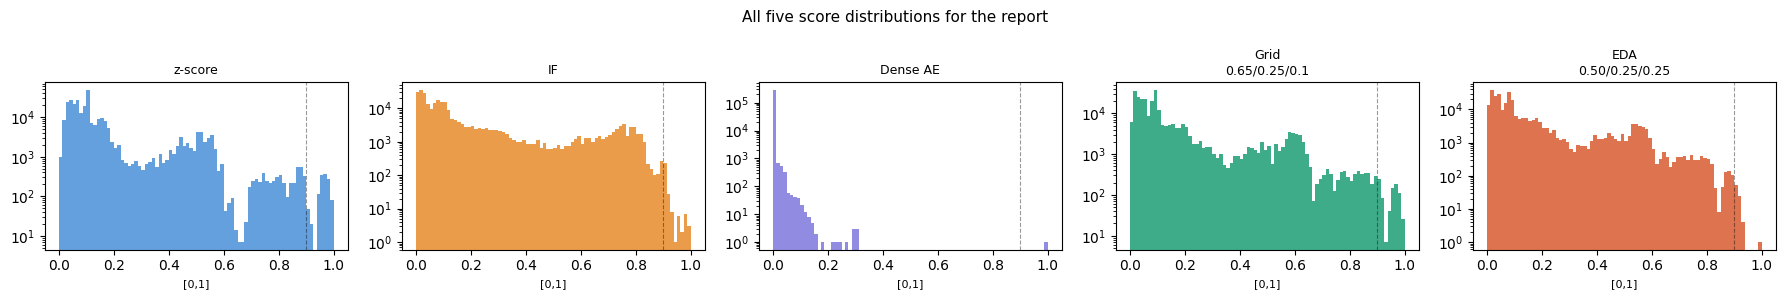

In [ ]:
# Version A: grid-searched weights
ensemble_grid = W_Z*z_sc + W_IF*if_sc + W_AE*ae_sc
ensemble_grid = (ensemble_grid - ensemble_grid.min()) / (ensemble_grid.max() - ensemble_grid.min() + 1e-9)

# Version B: EDA-justified weights
ensemble_eda  = 0.50*z_sc + 0.25*if_sc + 0.25*ae_sc
ensemble_eda  = (ensemble_eda - ensemble_eda.min()) / (ensemble_eda.max() - ensemble_eda.min() + 1e-9)

print("Comparison ")
print(f"{'Detector/Ensemble':<35} {'> 0.5':>8} {'> 0.7':>8} {'> 0.9':>8}")
for label, sc in [
    ('z-score only',  z_sc),
    ('Isolation Forest only', if_sc),
    ('Dense AE only',  ae_sc),
    (f'Ensemble (grid {W_Z}/{W_IF}/{W_AE})',  ensemble_grid),
    ('Ensemble (EDA 0.50/0.25/0.25)', ensemble_eda),
]:
    print(f"{label:<35} {(sc>0.5).sum():>8,} {(sc>0.7).sum():>8,} {(sc>0.9).sum():>8,}")

# Visualise all five scores
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, score, label, color in zip(axes,
    [z_sc, if_sc, ae_sc, ensemble_grid, ensemble_eda],
    ['z-score', 'IF', 'Dense AE', f'Grid\n{W_Z}/{W_IF}/{W_AE}', 'EDA\n0.50/0.25/0.25'],
    ['#4A90D9', '#E88B2A', '#7F77DD', '#1D9E75', '#D85A30']
):
    ax.hist(score, bins=80, color=color, alpha=0.85, edgecolor='none')
    ax.set_title(label, fontsize=9); ax.set_yscale('log'); ax.set_xlabel('[0,1]', fontsize=8)
    ax.axvline(0.9, color='black', linestyle='--', alpha=0.4, linewidth=0.8)

plt.suptitle('All five score distributions for the report', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}all_scores_report.png', dpi=120, bbox_inches='tight')
plt.show()


In [19]:
# Save both ensemble submissions
def save_sub(scores, fname):
    sub = pd.DataFrame({'ID': test['index'].values, 'TARGET': scores})
    sub.to_csv(OUTPUT_DIR + fname, index=False)
    print(f"Saved: {fname:<45}  (score>0.9: {(scores>0.9).sum():,}  max: {scores.max():.4f})")
    return sub

save_sub(ensemble_grid, f'submission_ensemble_grid_{W_Z}_{W_IF}_{W_AE}.csv')
save_sub(ensemble_eda,  'submission_ensemble_eda_0.50_0.25_0.25.csv')

Saved: submission_ensemble_grid_0.65_0.25_0.1.csv     (score>0.9: 848  max: 1.0000)
Saved: submission_ensemble_eda_0.50_0.25_0.25.csv     (score>0.9: 84  max: 1.0000)


,ID,TARGET
0,0,0.072496
1,1,0.470162
2,2,0.540487
3,3,0.573364
4,4,0.540487
...,...,...
289096,289096,0.014708
289097,289097,0.079147
289098,289098,0.015142
289099,289099,0.006867
